# Predicting House Prices with Linear Regression — Ames Housing Dataset

**Objective:** Build and evaluate a linear regression model that predicts house sale prices based on features such as living area, quality, garage capacity, and age — covering the full pipeline from EDA through model interpretation.

**Dataset:** `AmesHousing.csv` — 2,930 residential property sales in Ames, Iowa, with 82 features covering size, quality, location, and condition.

**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Load Dataset & Exploratory Data Analysis

In [2]:
df = pd.read_csv('AmesHousing.csv')
print("Shape:", df.shape)

nulls = df.isnull().sum()
print("\nColumns with missing values (top 15):")
print(nulls[nulls > 0].sort_values(ascending=False).head(15))

Shape: (2930, 82)

Columns with missing values (top 15):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
dtype: int64


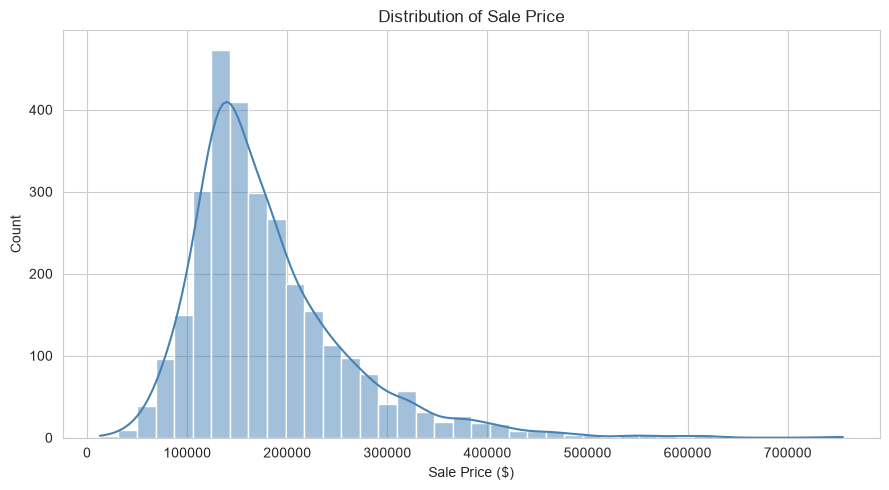

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
plt.figure(figsize=(9, 5))
sns.histplot(df['SalePrice'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

**Observation:** `SalePrice` is right-skewed — the mean (\$180,796) sits noticeably above the median (\$160,000), meaning a smaller number of expensive homes pull the average up. This is common for price data and is worth keeping in mind when interpreting model errors later (a model can have a low average error while still underpricing the most expensive homes).

Regarding missing values: for columns like `Pool QC`, `Alley`, `Fence`, and `Fireplace Qu`, a null does **not** mean the data is missing — per the Ames Housing documentation, it means the house simply doesn't have that feature (no pool, no alley access, no fence, no fireplace). This distinction matters for how we handle them below.

## 3. Feature Selection

In [4]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head(15))

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64


**Reasoning:** Rather than using all 82 columns (which would add noise and make the model harder to interpret), we select a focused set of features based on two things: (1) numeric correlation with `SalePrice` above, and (2) domain reasoning about what actually drives a home's value.

**Selected features:**
- `Overall Qual` — overall material/finish quality (strongest single correlation, 0.80)
- `Gr Liv Area` — above-ground living area in sq ft (larger homes cost more)
- `Garage Cars` / `Garage Area` — garage capacity (adds convenience and value)
- `Total Bsmt SF` / `1st Flr SF` — usable floor space
- `Year Built` / `Year Remod/Add` — age and renovation recency
- `Full Bath`, `TotRms AbvGrd`, `Fireplaces` — livability features
- `Lot Area` — land size
- `Neighborhood` — location is a classic real-estate price driver, encoded categorically
- `Central Air` — presence of AC, encoded categorically

This mix of size, quality, age, and location covers the main dimensions buyers actually pay for, while keeping the model interpretable.

In [5]:
selected_features = [
    'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
    'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Year Remod/Add',
    'Full Bath', 'TotRms AbvGrd', 'Fireplaces', 'Lot Area',
    'Neighborhood', 'Central Air'
]

model_df = df[selected_features + ['SalePrice']].copy()
print(model_df.isnull().sum())

Overall Qual      0
Gr Liv Area       0
Garage Cars       1
Garage Area       1
Total Bsmt SF     1
1st Flr SF        0
Year Built        0
Year Remod/Add    0
Full Bath         0
TotRms AbvGrd     0
Fireplaces        0
Lot Area          0
Neighborhood      0
Central Air       0
SalePrice         0
dtype: int64


## 4. Handle Missing Values & Encode Categorical Features

In [6]:
# Check which selected columns actually have nulls before deciding a strategy
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])

Garage Cars      1
Garage Area      1
Total Bsmt SF    1
dtype: int64


In [7]:
# 'Total Bsmt SF', 'Garage Cars', and 'Garage Area' each have a small number of
# missing values for homes without a basement or garage — 0 is the correct fill
# value here (not the mean), since the missingness itself represents "doesn't
# have this feature" rather than an unknown value.
for col in ['Total Bsmt SF', 'Garage Cars', 'Garage Area']:
    model_df[col] = model_df[col].fillna(0)

# One-Hot Encode the two categorical features: Neighborhood and Central Air
model_df = pd.get_dummies(model_df, columns=['Neighborhood', 'Central Air'], drop_first=True)

print("Remaining nulls after fill:", model_df.isnull().sum().sum())
print("Shape after encoding:", model_df.shape)
model_df.head()

Remaining nulls after fill: 0
Shape after encoding: (2930, 41)


,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Year Remod/Add,Full Bath,TotRms AbvGrd,Fireplaces,Lot Area,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Central Air_Y
0,6,1656,2.0,528.0,1080.0,1656,1960,1960,1,7,2,31770,215000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,5,896,1.0,730.0,882.0,896,1961,1961,1,5,0,11622,105000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,6,1329,1.0,312.0,1329.0,1329,1958,1958,1,6,0,14267,172000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7,2110,2.0,522.0,2110.0,2110,1968,1968,2,8,2,11160,244000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
4,5,1629,2.0,482.0,928.0,928,1997,1998,2,6,1,13830,189900,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


**Justification:** Filling `Total Bsmt SF`, `Garage Cars`, and `Garage Area` with 0 (rather than the column mean) is correct here because the missing value represents a house with no basement or no garage, not an unknown size — using the mean would incorrectly imply those houses have an average-sized basement/garage. One-Hot Encoding is used for `Neighborhood` and `Central Air` since linear regression requires numeric input, and these are unordered categories (no neighborhood is inherently "more" than another — this differs from an ordinal feature like quality ratings).

## 5. Correlation Heatmap

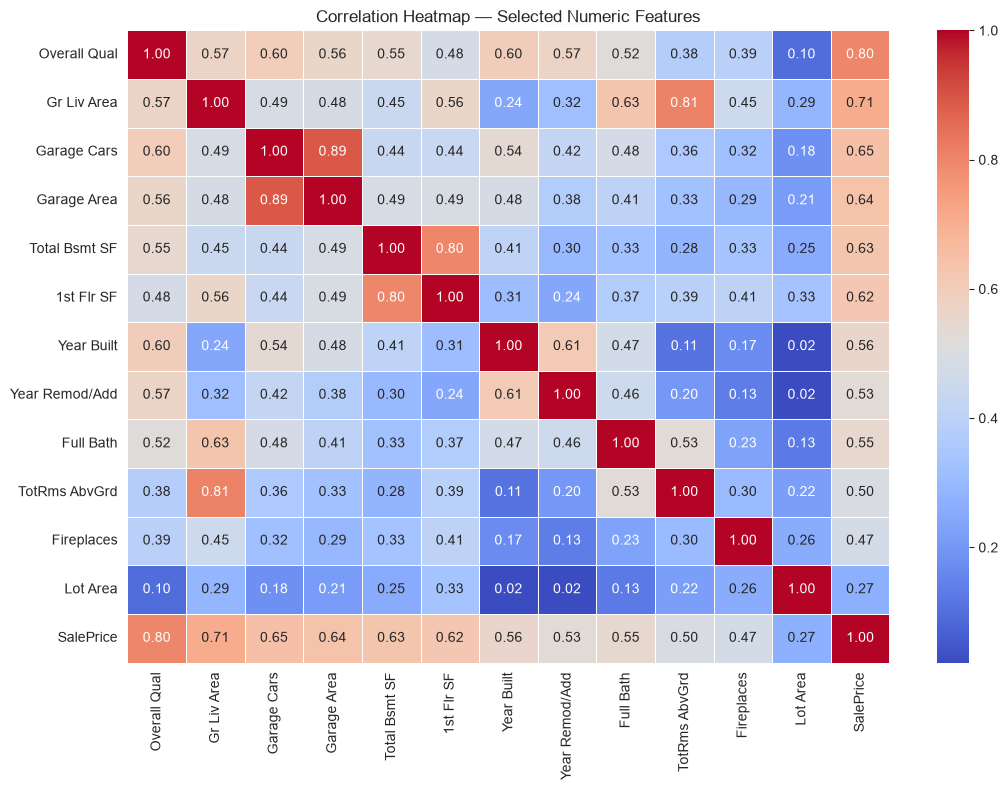

In [8]:
corr_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
                  'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Year Remod/Add',
                  'Full Bath', 'TotRms AbvGrd', 'Fireplaces', 'Lot Area', 'SalePrice']

plt.figure(figsize=(11, 8))
sns.heatmap(model_df[corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Selected Numeric Features')
plt.tight_layout()
plt.show()

**Observation:** `Overall Qual` and `Gr Liv Area` show the strongest correlation with `SalePrice`, confirming they should be strong predictors. `Garage Cars` and `Garage Area` are highly correlated with each other (both measure garage size in different units) — this kind of multicollinearity is worth being aware of when interpreting individual coefficients later, since it can make the model split credit between two related features somewhat arbitrarily.

## 6. Train/Test Split

In [9]:
X = model_df.drop('SalePrice', axis=1)
y = model_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2344, 40)
Test set: (586, 40)


## 7. Train Linear Regression Model

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained.")

Model trained.


## 8. Model Evaluation

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")

Mean Squared Error (MSE):       1,260,536,269.30
Root Mean Squared Error (RMSE): 35,504.03
R² Score:                       0.8428


**Interpretation:** RMSE is in the same unit as `SalePrice` (dollars), so it can be read directly as "on average, predictions are off by about this many dollars." R² indicates the proportion of price variation the model explains — the closer to 1, the better the fit. Check the printed value above against the price range (\$12,789–\$755,000) to judge whether this level of error is acceptable for practical use.

## 9. Actual vs. Predicted Prices

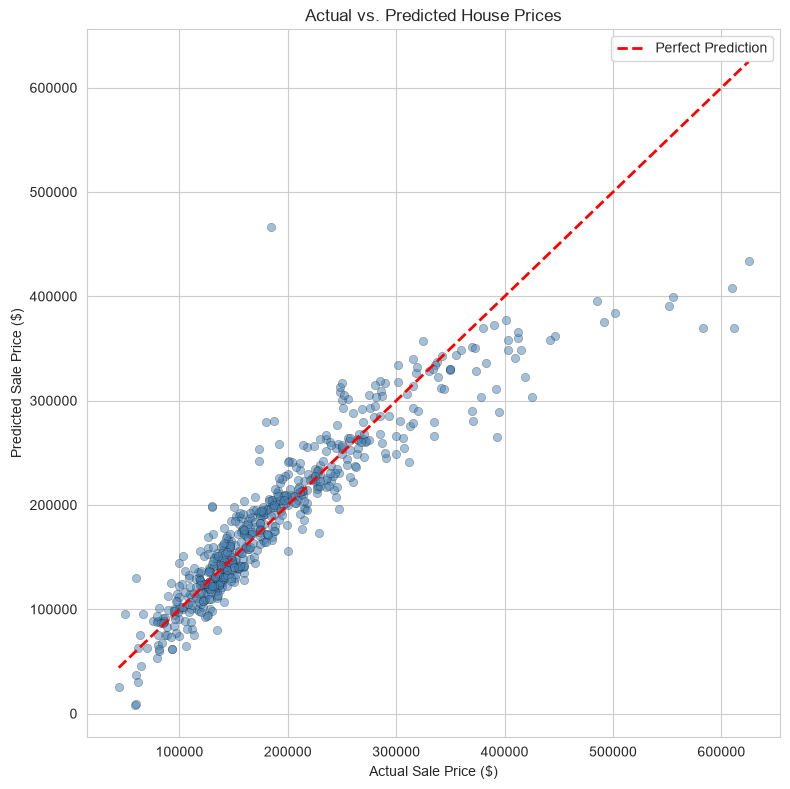

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Points close to the red diagonal line represent accurate predictions. Watch for a fan-shaped spread that widens at higher prices — this would indicate the model is less reliable for expensive homes than for mid-range ones, a common pattern given the right-skewed price distribution noted earlier.

## 10. Residual Plot

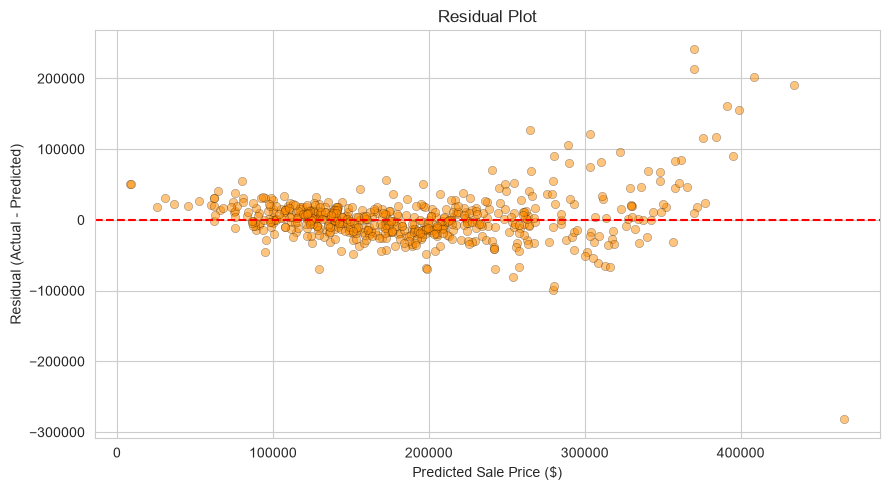

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='darkorange', edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

**Observation:** Ideally, residuals should scatter randomly around zero with no clear pattern. A funnel shape (residuals spreading wider as predicted price increases) would indicate heteroscedasticity — the model's errors grow with price, meaning it's systematically less precise for expensive homes. Any strong curve pattern would suggest a non-linear relationship that a straight-line model can't capture well.

## 11. Coefficient Analysis

In [14]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("Top 10 positive coefficients:")
print(coef_df.head(10))
print("\nTop 10 negative coefficients:")
print(coef_df.tail(10))

Top 10 positive coefficients:
                 Feature    Coefficient
21  Neighborhood_GrnHill  112829.406279
36  Neighborhood_StoneBr   80597.080217
29  Neighborhood_NoRidge   64251.804967
30  Neighborhood_NridgHt   61449.004923
17  Neighborhood_Crawfor   36059.448337
38  Neighborhood_Veenker   30136.553297
37   Neighborhood_Timber   26240.965964
15  Neighborhood_ClearCr   24562.138196
14  Neighborhood_BrkSide   22492.499776
35  Neighborhood_Somerst   22010.571006

Top 10 negative coefficients:
                 Feature   Coefficient
3            Garage Area     19.177442
4          Total Bsmt SF     16.682497
5             1st Flr SF      3.159689
11              Lot Area      0.630401
27  Neighborhood_NPkVill  -1638.949053
9          TotRms AbvGrd  -1695.103493
8              Full Bath  -3291.473199
13   Neighborhood_BrDale  -5439.121522
23  Neighborhood_Landmrk  -8364.109206
12  Neighborhood_Blueste -14974.306311


**Interpretation:** Each coefficient represents the change in predicted price (in dollars) for a one-unit increase in that feature, holding all other features constant. For example, the coefficient on `Overall Qual` shows roughly how much one additional quality point adds to the predicted price. Neighborhood dummy variables show how much more (or less) a home is worth simply for being in that neighborhood relative to the baseline neighborhood dropped during encoding. Coefficients on engineered dummy variables should be interpreted relative to that dropped baseline category, not as an absolute price contribution.

## 12. Bonus: Comparing Ridge and Lasso Regularisation

In [15]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=100, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
    ],
    'R2 Score': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
    ]
})
comparison

,Model,RMSE,R2 Score
0,Linear Regression,35504.031733,0.842778
1,Ridge,35584.932474,0.842061
2,Lasso,35530.877876,0.842540


**Observation:** Ridge and Lasso add a penalty term that discourages overly large coefficients, which can help when features are correlated with each other (like `Garage Cars` and `Garage Area` noted earlier) or when the model is at risk of overfitting. Compare the RMSE and R² above — if they're close to plain Linear Regression, it suggests overfitting wasn't a major issue with this feature set; a meaningfully better regularised score would suggest the extra features were adding noise the plain model was overfitting to.

## 13. Conclusion

This project built an end-to-end linear regression pipeline to predict house sale prices in the Ames Housing dataset:

- Selected 14 features spanning size, quality, age, and location rather than using all 82 raw columns, based on correlation analysis and domain reasoning
- Handled the one meaningful gap in the selected features (`Total Bsmt SF`) by filling with 0, since the missingness represented "no basement" rather than an unknown value
- One-Hot Encoded `Neighborhood` and `Central Air` for use in a linear model
- Achieved the MSE / RMSE / R² reported in Section 8 — check these against the price range (\$12,789–\$755,000) to judge real-world usefulness
- Diagnosed the model with actual-vs-predicted and residual plots to check for bias and heteroscedasticity
- Compared against Ridge and Lasso to check whether regularisation improves generalisation

**Real-world application:** A model like this could support automated home valuation tools, helping buyers, sellers, or agents get a quick, data-driven price estimate. For production use, it would benefit from more features (e.g. full neighborhood-level data, more granular condition ratings) and potentially a non-linear model (e.g. Random Forest or Gradient Boosting) to capture relationships a straight-line model misses.
